### IMS bearings — distribution shift

`DataTransformer` splits each channel chronologically (healthy head = train + val,
everything after = test) and z-scores it with **train** statistics.

If a fault changes the vibration, the test amplitude distribution should get wider and
heavier-tailed on the four damaged channels, and stay put on the other twelve.

In [1]:
import os

os.chdir('..')
os.getcwd()

'c:\\Users\\chouybat\\repositories\\phm-101'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from phm_101.data_pipeline.data_loader import DataLoader
from phm_101.data_pipeline.data_transformer import DataTransformer
from phm_101.utils.ims import CHANNELS

loader = DataLoader()
transformer = DataTransformer()

all_channels = [c for channels in CHANNELS.values() for c in channels]

### one channel end to end

In [3]:
data = loader.load('t2b1')
split = transformer.train_test_split(data)
transformer.fit(split.train)

parts = {
    'train': transformer.transform(split.train),
    'val': transformer.transform(split.val),
    'test': transformer.transform(split.test),
}

pd.DataFrame([
    {
        'part': name,
        'snapshots': len(part),
        'faulty': int(part.labels.sum()),
        'from': part.timestamps[0],
        'to': part.timestamps[-1],
        'mean': part.signals.mean(),
        'std': part.signals.std(),
    }
    for name, part in parts.items()
])

2026-08-25 18:18:42.518 | INFO     | phm_101.data_pipeline.data_loader:load:51 - Loading IMS raw signals from parquet file for channel t2b1
2026-08-25 18:18:42.632 | INFO     | phm_101.data_pipeline.data_loader:load:81 - Terminated loading IMS raw signals from parquet file for channel t2b1
2026-08-25 18:18:42.635 | INFO     | phm_101.data_pipeline.data_transformer:train_test_split:34 - Split t2b1: 447 train, 111 val, 424 test
2026-08-25 18:18:42.651 | INFO     | phm_101.data_pipeline.data_transformer:fit:51 - Fitted mean=-0.001966 std=0.077178


,part,snapshots,faulty,from,to,mean,std
0,train,447,0,2004-02-12 10:32:39,2004-02-15 12:52:39,-1.082751e-08,1.000000
1,val,111,0,2004-02-15 13:02:39,2004-02-16 07:22:39,-3.553942e-04,1.029731
2,test,424,280,2004-02-16 07:32:39,2004-02-19 06:02:39,6.339094e-04,2.091198


### amplitude distribution

A log y-axis is what matters here: a bearing defect shows up as rare, large impacts, so
the difference lives in the **tails**, not near the peak.

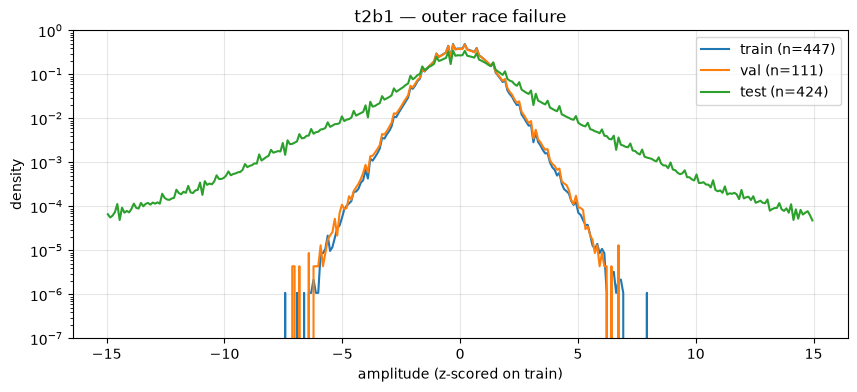

In [4]:
BINS = np.linspace(-15, 15, 300)
MAX_SNAPSHOTS = 300  # subsample so the whole grid stays fast


def pdf(signals: np.ndarray) -> np.ndarray:
    """Normalised histogram of the sample amplitudes."""
    stride = max(1, len(signals) // MAX_SNAPSHOTS)
    values = signals[::stride].ravel()
    density, _ = np.histogram(values, bins=BINS, density=True)
    return density


centres = (BINS[:-1] + BINS[1:]) / 2

plt.figure(figsize=(10, 4))
for name, part in parts.items():
    plt.plot(centres, pdf(part.signals), label=f'{name} (n={len(part)})')

plt.yscale('log')
plt.ylim(1e-7, 1)
plt.xlabel('amplitude (z-scored on train)')
plt.ylabel('density')
plt.title(f'{data.channel} — outer race failure')
plt.legend()
plt.grid(alpha=0.3)

Train and val sit on top of each other — good, the split is not accidentally shifting
anything on its own. The test curve is the fault.

### every channel

Takes a minute: each channel is loaded, split, fitted and reduced to histograms, then
the signals are dropped so memory stays flat.

In [5]:
densities = {}
rows = []


def subsample(signals: np.ndarray) -> np.ndarray:
    stride = max(1, len(signals) // MAX_SNAPSHOTS)
    return signals[::stride].ravel().astype(np.float64)


for channel in all_channels:
    d = loader.load(channel)
    s = transformer.train_test_split(d)
    transformer.fit(s.train)

    train = transformer.transform(s.train).signals
    test = transformer.transform(s.test).signals
    densities[channel] = {'train': pdf(train), 'test': pdf(test)}

    a, b = subsample(train), subsample(test)
    rows.append({
        'channel': channel,
        'failed': bool(d.labels.sum()),
        'std_ratio': b.std() / a.std(),
        'tail_ratio': (
            np.quantile(np.abs(b), 0.9999) / np.quantile(np.abs(a), 0.9999)
        ),
        'test_kurtosis': ((b - b.mean()) ** 4).mean() / b.std() ** 4 - 3,
    })
    del d, s, train, test, a, b

shift = pd.DataFrame(rows)
shift.round(2)

2026-08-25 18:19:14.185 | INFO     | phm_101.data_pipeline.data_loader:load:51 - Loading IMS raw signals from parquet file for channel t1b1_x
2026-08-25 18:19:14.350 | INFO     | phm_101.data_pipeline.data_loader:load:81 - Terminated loading IMS raw signals from parquet file for channel t1b1_x
2026-08-25 18:19:14.355 | INFO     | phm_101.data_pipeline.data_transformer:train_test_split:34 - Split t1b1_x: 1148 train, 287 val, 721 test
2026-08-25 18:19:14.398 | INFO     | phm_101.data_pipeline.data_transformer:fit:51 - Fitted mean=-0.114297 std=0.096948
2026-08-25 18:19:14.859 | INFO     | phm_101.data_pipeline.data_loader:load:51 - Loading IMS raw signals from parquet file for channel t1b1_y
2026-08-25 18:19:15.007 | INFO     | phm_101.data_pipeline.data_loader:load:81 - Terminated loading IMS raw signals from parquet file for channel t1b1_y
2026-08-25 18:19:15.013 | INFO     | phm_101.data_pipeline.data_transformer:train_test_split:34 - Split t1b1_y: 1148 train, 287 val, 721 test
2026-0

,channel,failed,std_ratio,tail_ratio,test_kurtosis
0,t1b1_x,False,1.05,1.05,1.01
1,t1b1_y,False,1.04,1.01,1.03
2,t1b2_x,False,1.07,1.11,0.48
3,t1b2_y,False,1.05,1.15,0.68
4,t1b3_x,True,1.23,3.15,24.65
5,t1b3_y,True,1.20,2.60,9.76
6,t1b4_x,True,1.72,2.66,5.18
7,t1b4_y,True,1.60,2.29,5.18
8,t2b1,True,2.09,7.01,38.28
9,t2b2,False,1.13,1.42,0.80


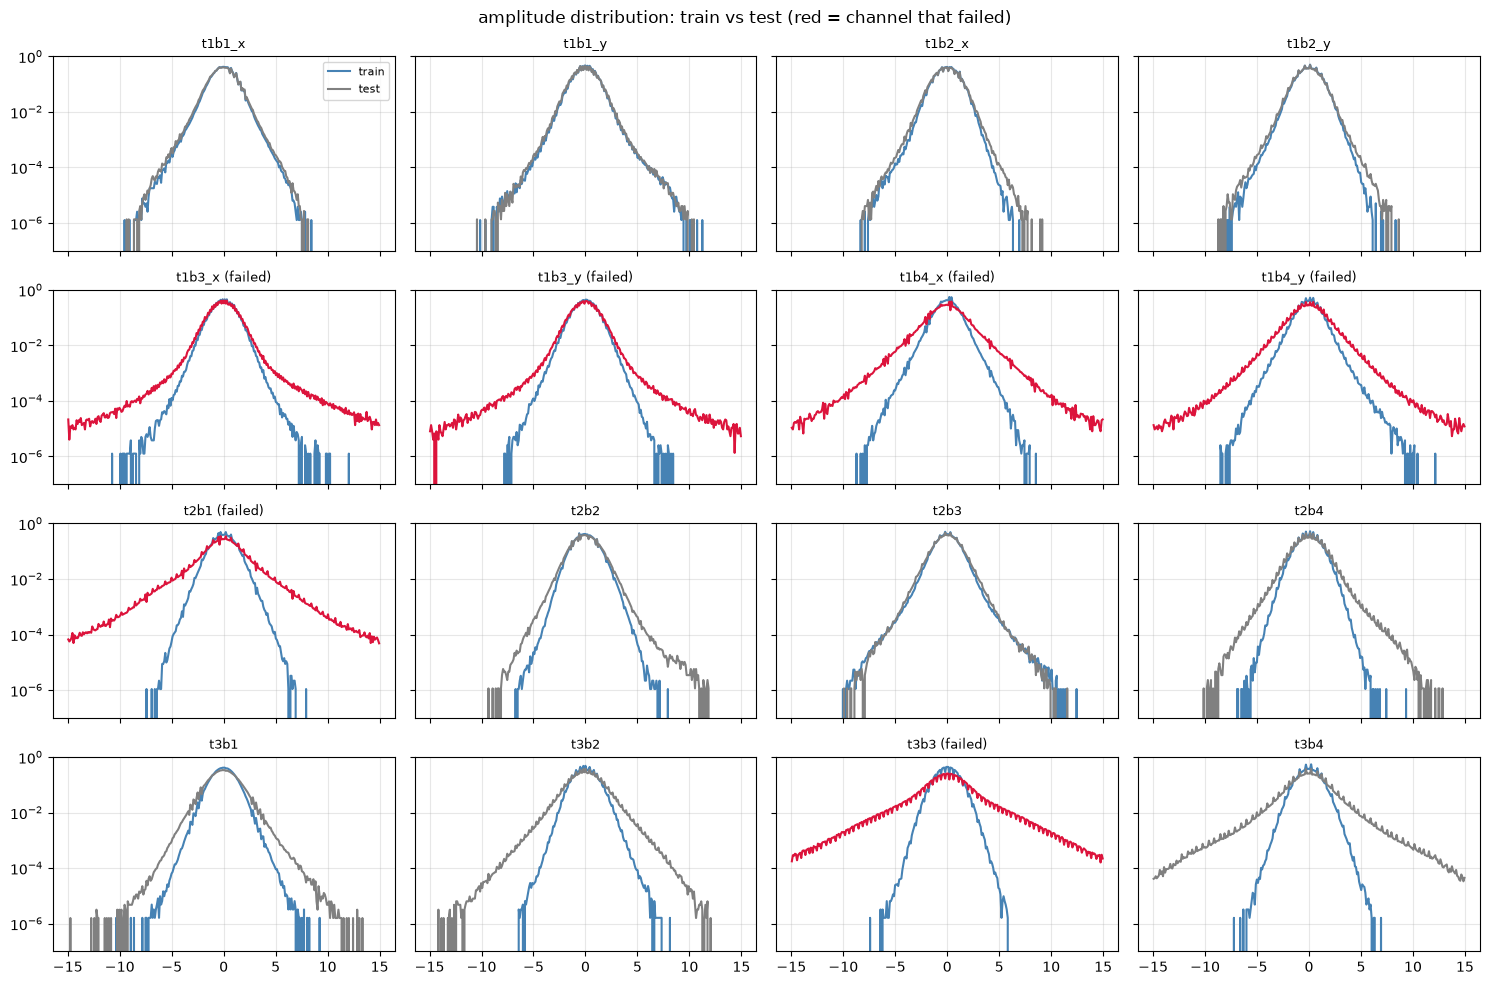

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(15, 10), sharex=True, sharey=True)

for ax, channel in zip(axes.ravel(), all_channels, strict=False):
    failed = bool(shift.set_index('channel').loc[channel, 'failed'])
    ax.plot(centres, densities[channel]['train'], color='steelblue', label='train')
    ax.plot(
        centres,
        densities[channel]['test'],
        color='crimson' if failed else 'grey',
        label='test',
    )
    ax.set_yscale('log')
    ax.set_ylim(1e-7, 1)
    ax.set_title(channel + (' (failed)' if failed else ''), fontsize=9)
    ax.grid(alpha=0.3)

axes[0, 0].legend(fontsize=8)
fig.suptitle('amplitude distribution: train vs test (red = channel that failed)')
fig.tight_layout()

### does the shift separate failed from healthy?

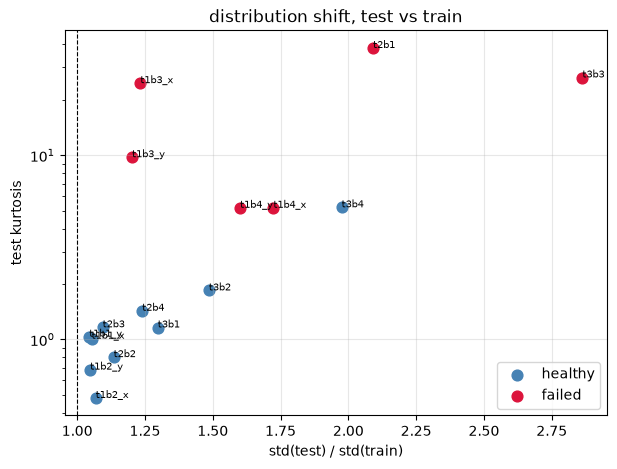

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

for failed, group in shift.groupby('failed'):
    ax.scatter(
        group['std_ratio'],
        group['test_kurtosis'],
        c='crimson' if failed else 'steelblue',
        label='failed' if failed else 'healthy',
        s=60,
    )
    for row in group.itertuples():
        ax.annotate(row.channel, (row.std_ratio, row.test_kurtosis), fontsize=7)

ax.axvline(1.0, ls='--', c='black', lw=0.8)
ax.set_xlabel('std(test) / std(train)')
ax.set_yscale('log')
ax.set_ylabel('test kurtosis')
ax.set_title('distribution shift, test vs train')
ax.legend()
ax.grid(alpha=0.3)

### what this says

All four damaged channels move right and up. So do several healthy ones — and none of
the three metrics cleanly separates the two groups:

| metric | failed | healthy | separates? |
|---|---|---|---|
| `std_ratio` | 1.20 – 2.86 | 1.04 – 1.98 | no |
| `tail_ratio` | 2.29 – 9.52 | 0.98 – 3.35 | no |
| `test_kurtosis` | 5.18 – 38.28 | 0.48 – 5.21 | no, by a hair |

`t3b4` is healthy yet shifts more than `t1b3_y`, `t1b4_x` and `t1b4_y`, which are all
damaged. Two reasons, and both matter for what comes next:

1. **Rig-wide vibration.** `t3b4` shares a shaft with `t3b3`. When `t3b3` spalls the
   whole rig shakes harder, and `t3b4` inherits that without being damaged itself.
2. **Pooling dilutes the fault.** These numbers describe the *entire* test window at
   once. `t1b4` has 665 faulty snapshots, most of them only mildly degraded, so its
   distribution is dominated by near-healthy data. `t3b3` collapses violently over a
   short window and looks dramatic by comparison. The metric is measuring how much of
   the window is degraded as much as how badly.

So a single pooled distribution per channel is not enough to detect a fault. What it
does establish is that the transform behaves correctly — train and val land on top of
each other, so the split introduces no shift of its own — and that any detector will
have to work **per snapshot over time**, the way `ims_eda` plots the trajectories,
rather than on the run as a whole.

One caveat on comparing across tests: the test windows are very unequal, about 306
snapshots for test 3 against 721 for test 1.